In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [98]:
df = pd.read_csv("../data/titanic3.csv")

In [99]:
df.head(2)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"


Keeping only the required columns

In [100]:
df = df[['pclass', 'sex', 'age', 'sibsp','parch', 'fare', 'embarked', 'survived']]

In [101]:
df.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.00,0,0,211.3375,S,1
1,1,male,0.92,1,2,151.5500,S,1


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   sex       1309 non-null   str    
 2   age       1046 non-null   float64
 3   sibsp     1309 non-null   int64  
 4   parch     1309 non-null   int64  
 5   fare      1308 non-null   float64
 6   embarked  1307 non-null   str    
 7   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 81.9 KB


Splitting the data into stratified training, validation, and test subsets using the `stratified_split` function we created

In [103]:
from src.splits import stratified_split

X_raw = df.drop(columns=["survived"])
y = df["survived"]

# Split before preprocessing so that imputation values are learned only from training data.
# The test set must remain untouched during model selection.
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = (
    stratified_split(X_raw.to_numpy(), y.to_numpy(), train_frac=0.6, val_frac=0.2, test_frac=0.2, seed=42))

In [104]:
print(X_train_raw.shape, y_train.shape)
print(X_val_raw.shape, y_val.shape)
print(X_test_raw.shape, y_test.shape)

(785, 7) (785,)
(262, 7) (262,)
(262, 7) (262,)


Reverting into DataFrames and Series accordingly

In [105]:
# Convert the split arrays back to DataFrames to preserve column names during preprocessing.
X_train_raw = pd.DataFrame(X_train_raw, columns=X_raw.columns)
X_val_raw = pd.DataFrame(X_val_raw, columns=X_raw.columns)
X_test_raw = pd.DataFrame(X_test_raw, columns=X_raw.columns)

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)
y_val = pd.Series(y_val)

In [106]:
numeric_columns = ["pclass", "age", "sibsp", "parch", "fare"]

# We should convert numeric columns back to numeric from object.
for subset in [X_train_raw, X_val_raw, X_test_raw]:
    subset[numeric_columns] = subset[numeric_columns].apply(pd.to_numeric)

y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

There exist three columns that contain null values: age, fare, embarked

The strategies will be:
1. median for 'age'
2. median for 'fare'
3. mode for 'embarked'

In [107]:
age_median = X_train_raw["age"].median()
fare_median = X_train_raw["fare"].median()
embarked_mode = X_train_raw["embarked"].mode()[0]

print(age_median, fare_median, embarked_mode)

29.0 14.5 S


In [108]:
print("Train missing values:", pd.isna(X_train_raw).sum().sum())
print("Val missing values:  ", pd.isna(X_val_raw).sum().sum())
print("Test missing values: ", pd.isna(X_test_raw).sum().sum())

Train missing values: 165
Val missing values:   46
Test missing values:  55


Filling the null values

In [109]:
for subset in [X_train_raw, X_val_raw, X_test_raw]:
    subset["age"] = subset["age"].fillna(age_median)
    subset["fare"] = subset["fare"].fillna(fare_median)
    subset["embarked"] = subset["embarked"].fillna(embarked_mode)

In [110]:
print("Train missing values:", pd.isna(X_train_raw).sum().sum())
print("Val missing values:  ", pd.isna(X_val_raw).sum().sum())
print("Test missing values: ", pd.isna(X_test_raw).sum().sum())

Train missing values: 0
Val missing values:   0
Test missing values:  0


Next, we one-hot encode two columns: 'sex' and 'embarked'

In [111]:
X_train_encoded = pd.get_dummies(X_train_raw, columns=["sex", "embarked"], dtype=int)
X_val_encoded = pd.get_dummies(X_val_raw, columns=["sex", "embarked"], dtype=int)
X_test_encoded = pd.get_dummies(X_test_raw, columns=["sex", "embarked"], dtype=int)

In [112]:
X_train_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      785 non-null    int64  
 1   age         785 non-null    float64
 2   sibsp       785 non-null    int64  
 3   parch       785 non-null    int64  
 4   fare        785 non-null    float64
 5   sex_female  785 non-null    int64  
 6   sex_male    785 non-null    int64  
 7   embarked_C  785 non-null    int64  
 8   embarked_Q  785 non-null    int64  
 9   embarked_S  785 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 61.5 KB


Ensure that columns are going to be in the same order

In [113]:
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train = X_train_encoded.to_numpy(dtype=float)
X_val = X_val_encoded.to_numpy(dtype=float)
X_test = X_test_encoded.to_numpy(dtype=float)

y_train = y_train.to_numpy(dtype=int)
y_val = y_val.to_numpy(dtype=int)
y_test = y_test.to_numpy(dtype=int)

In [114]:
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("Remaining train missing values:", pd.isna(X_train).sum())
print("Remaining val missing values:", pd.isna(X_val).sum())
print("Remaining test missing values:", pd.isna(X_test).sum())

print("Training columns:", X_train_encoded.columns.tolist())
print("Validation columns match:", X_val_encoded.columns.equals(X_train_encoded.columns))
print("Test columns match:", X_test_encoded.columns.equals(X_train_encoded.columns))

Training shape: (785, 10) (785,)
Validation shape: (262, 10) (262,)
Test shape: (262, 10) (262,)
Remaining train missing values: 0
Remaining val missing values: 0
Remaining test missing values: 0
Training columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
Validation columns match: True
Test columns match: True


From now on, we are moving to Hyperparameter sweep.
We have to evaluate our model with the exact values provided.

In [115]:
from src.knn import KNN
from src.metrics import accuracy, precision, recall, f1_score, roc_auc

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
validation_results = []
print("Training classes:", np.unique(y_train))

Training classes: [0 1]


Next, we store the metric results for each k-value.

In [116]:
for k in k_values:
    model = KNN(k=k, metric="euclidean")
    model.fit(X_train, y_train)

    # Class labels are used for accuracy, precision, recall, and F1.
    y_val_pred = model.predict(X_val)
    # ROC-AUC requires the predicted probability of the positive class.
    y_val_score = model.predict_proba(X_val)[:, 1]

    result = {
        "k": k,
        "accuracy": accuracy(y_val, y_val_pred),
        "precision": precision(y_val, y_val_pred),
        "recall": recall(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc(y_val, y_val_score),
    }

    validation_results.append(result)

In [117]:
validation_results_df = pd.DataFrame(validation_results)
validation_results_df

,k,accuracy,precision,recall,f1,roc_auc
0,1,0.667939,0.564356,0.57,0.567164,0.649198
1,3,0.667939,0.568421,0.54,0.553846,0.668488
2,5,0.652672,0.545455,0.54,0.542714,0.658549
3,7,0.641221,0.534091,0.47,0.500000,0.658827
4,9,0.660305,0.566265,0.47,0.513661,0.672778
5,11,0.660305,0.567901,0.46,0.508287,0.682037
6,15,0.667939,0.582278,0.46,0.513966,0.692346
7,21,0.671756,0.592105,0.45,0.511364,0.706975
8,31,0.675573,0.611940,0.41,0.491018,0.704753
9,51,0.683206,0.639344,0.39,0.484472,0.715216


We can observe the results from the table above.
We have to select k using validation F1 only.

In [118]:
best_row_index = validation_results_df["f1"].idxmax()
best_k = int(validation_results_df.loc[best_row_index, "k"])

print("Best k based on validation F1:", best_k)
print("Best validation F1:", validation_results_df.loc[best_row_index, "f1"])

Best k based on validation F1: 1
Best validation F1: 0.5671641791044776


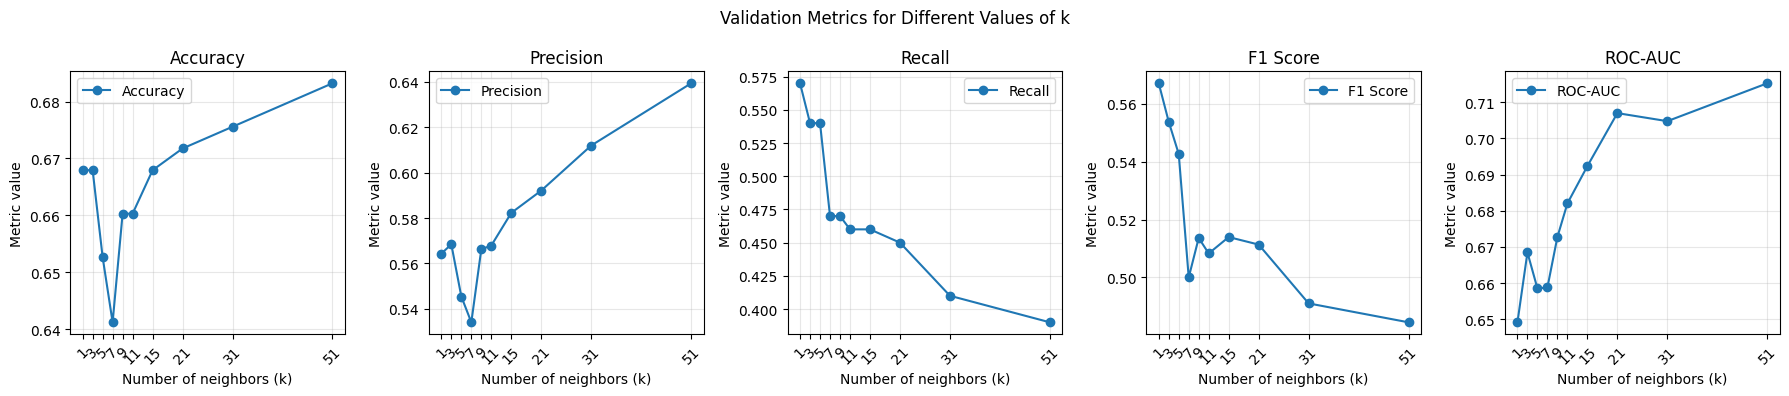

Saved figure to: ..\figures\validation_metrics_vs_k.pdf


In [119]:
from pathlib import Path

metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_titles = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

# Create one panel for each required validation metric.
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, metric, title in zip(axes, metric_columns, metric_titles):
    ax.plot(
        validation_results_df["k"],
        validation_results_df[metric],
        marker="o",
        label=title,
    )

    ax.set_title(title)
    ax.set_xlabel("Number of neighbors (k)")
    ax.set_ylabel("Metric value")
    ax.set_xticks(k_values)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Validation Metrics for Different Values of k")
fig.tight_layout()

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

# Save the figure as a PDF so it can be referenced in the final report.
figure_path = figures_dir / "validation_metrics_vs_k.pdf"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved figure to:", figure_path)

In [120]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Custom KNN with the selected value of k
custom_knn = KNN(k=best_k, metric="euclidean")
custom_knn.fit(X_train, y_train)

custom_val_pred = custom_knn.predict(X_val)
custom_val_score = custom_knn.predict_proba(X_val)[:, 1]


# 2. Majority-class baseline
classes, counts = np.unique(y_train, return_counts=True)
majority_class = classes[np.argmax(counts)]

# Predict the most common training class for every validation sample.
majority_val_pred = np.full(y_val.shape, majority_class)

# Use a constant score for ROC-AUC because the baseline cannot rank samples.
positive_class_probability = np.mean(y_train == 1)
majority_val_score = np.full(y_val.shape, positive_class_probability, dtype=float)


# 3. Scikit-learn KNN with the same settings
sklearn_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean",
)

sklearn_knn.fit(X_train, y_train)

sklearn_val_pred = sklearn_knn.predict(X_val)
sklearn_val_score = sklearn_knn.predict_proba(X_val)[:, 1]

In [121]:
print("Selected best_k:", best_k)
print("Majority class:", majority_class)
print("Training positive-class proportion:", positive_class_probability)

Selected best_k: 1
Majority class: 0
Training positive-class proportion: 0.3821656050955414


In [122]:
print(
    "Custom and sklearn predictions match:",
    np.array_equal(custom_val_pred, sklearn_val_pred),
)

print(
    "Custom and sklearn probabilities match:",
    np.allclose(custom_val_score, sklearn_val_score, atol=1e-9),
)

Custom and sklearn predictions match: False
Custom and sklearn probabilities match: False


In [123]:
prediction_mismatches = np.sum(custom_val_pred != sklearn_val_pred)
probability_mismatches = np.sum(
    ~np.isclose(custom_val_score, sklearn_val_score, atol=1e-9)
)

print("Prediction mismatches:", prediction_mismatches)
print("Probability mismatches:", probability_mismatches)
print("Validation samples:", len(y_val))

Prediction mismatches: 7
Probability mismatches: 7
Validation samples: 262


In [124]:
# Inspect one disagreement between custom KNN and sklearn KNN.
mismatch_indices = np.where(custom_val_pred != sklearn_val_pred)[0]
first_mismatch = mismatch_indices[0]

# Calculate distances from one validation sample to every training sample.
distances = np.sqrt(
    np.sum((X_train - X_val[first_mismatch]) ** 2, axis=1)
)

minimum_distance = np.min(distances)

# Find all training rows tied at the minimum distance.
tied_neighbor_indices = np.where(
    np.isclose(distances, minimum_distance)
)[0]

print("First mismatch index:", first_mismatch)
print("Minimum distance:", minimum_distance)
print("Number of equally close neighbors:", len(tied_neighbor_indices))
print("Labels of equally close neighbors:", y_train[tied_neighbor_indices])

print("Custom prediction:", custom_val_pred[first_mismatch])
print("Sklearn prediction:", sklearn_val_pred[first_mismatch])

First mismatch index: 20
Minimum distance: 2.227105745132009
Number of equally close neighbors: 3
Labels of equally close neighbors: [0 1 0]
Custom prediction: 1
Sklearn prediction: 0


Baseline results will be stored in a DataFrame.

In [125]:
baseline_results = [
    {
        "model": "Custom KNN",
        "accuracy": accuracy(y_val, custom_val_pred),
        "precision": precision(y_val, custom_val_pred),
        "recall": recall(y_val, custom_val_pred),
        "f1": f1_score(y_val, custom_val_pred),
        "roc_auc": roc_auc(y_val, custom_val_score),
    },
    {
        "model": "Majority baseline",
        "accuracy": accuracy(y_val, majority_val_pred),
        "precision": precision(y_val, majority_val_pred),
        "recall": recall(y_val, majority_val_pred),
        "f1": f1_score(y_val, majority_val_pred),
        "roc_auc": roc_auc(y_val, majority_val_score),
    },
    {
        "model": "Sklearn KNN",
        "accuracy": accuracy(y_val, sklearn_val_pred),
        "precision": precision(y_val, sklearn_val_pred),
        "recall": recall(y_val, sklearn_val_pred),
        "f1": f1_score(y_val, sklearn_val_pred),
        "roc_auc": roc_auc(y_val, sklearn_val_score),
    },
]

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Custom KNN,0.667939,0.564356,0.57,0.567164,0.649198
1,Majority baseline,0.618321,0.000000,0.00,0.000000,0.500000
2,Sklearn KNN,0.679389,0.580000,0.58,0.580000,0.660370


In [126]:
# Evaluate the selected model on the held-out test set exactly once.
# best_k was already fixed using validation F1 and must not be changed afterward.
final_knn = KNN(k=best_k, metric="euclidean")
final_knn.fit(X_train, y_train)

y_test_pred = final_knn.predict(X_test)
y_test_score = final_knn.predict_proba(X_test)[:, 1]

test_results = {
    "model": "Custom KNN",
    "k": best_k,
    "accuracy": accuracy(y_test, y_test_pred),
    "precision": precision(y_test, y_test_pred),
    "recall": recall(y_test, y_test_pred),
    "f1": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc(y_test, y_test_score),
}

test_results_df = pd.DataFrame([test_results])

test_results_df

,model,k,accuracy,precision,recall,f1,roc_auc
0,Custom KNN,1,0.648855,0.539216,0.55,0.544554,0.629938
